 # Von Neumann Stability Analysis


In the previous tuorial we observe some stability procedures we use to stabilize the FDM/FVM. Now we shall see mathematical proof how do they stbailize using Von Neumann stability analysis. At the ned we will compare how accurate this analysis with the simulation results.


 Von Neumann stability analysis is a Fourier-based method used to determine whether a numerical scheme is stable.
 The key idea is to analyze how numerical errors evolve in time.



 If errors grow → scheme is unstable

 If errors decay or remain bounded → scheme is stable



 ---



 We consider the 1D linear convection equation:



 $$

 \frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0

 $$



 where



 - $u(x,t)$ is the transported variable

 - $c$ is constant velocity



 ## Fourier Representation of Numerical Error



 Assume the numerical solution contains an error mode:



 $$

 \epsilon_i^n = G^n e^{i k x_i}

 $$



 where:



 - $G$ = amplification factor

 - $k$ = wavenumber

 - $x_i = i\Delta x$



 If:



 $$

 |G| \le 1

 $$



 the scheme is stable.



 If:



 $$

 |G| > 1

 $$



 the scheme is unstable.



 ## Steps in Von Neumann Analysis



 1. Write the numerical scheme



 2. Assume Fourier mode:



 $$

 u_i^n = G^n e^{i k i \Delta x}

 $$



 3. Substitute into the discrete equation



 4. Simplify to obtain amplification factor $G$



 5. Compute magnitude $|G|$



 6. Determine stability condition



 # FTBS Scheme



 Discretization:



 $$

 u_i^{n+1}

 =

 u_i^n

 -

CFL (u_i^n - u_{i-1}^n)

 $$



 where



 $$

CFL = \frac{c\Delta t}{\Delta x}

 $$



 ---



 Substitute Fourier mode:



 $$

 u_i^n = G^n e^{i k i\Delta x}

 $$



 After simplification:



 $$

 G = 1 - CFL (1 - e^{-ik\Delta x})

 $$



 Stability condition:



 $$

 0 \le CFL \le 1

 $$



 FTBS is stable because it introduces numerical diffusion.



 # FTFS Scheme



 Discretization:



 $$

 u_i^{n+1}

 =

 u_i^n

 -

 \mu (u_{i+1}^n - u_i^n)

 $$



 Amplification factor:



 $$

 G = 1 - \mu (e^{ik\Delta x} - 1)

 $$



 Magnitude:



 $$

 |G| > 1

 $$



 Therefore FTFS is **unconditionally unstable** for $c>0$.



 # FTCS Scheme



 Discretization:



 $$

 u_i^{n+1}

 =

 u_i^n

 -

 \frac{\mu}{2}(u_{i+1}^n - u_{i-1}^n)

 $$



 Amplification factor:



 $$

 G = 1 - i\mu \sin(k\Delta x)

 $$



 Magnitude:



 $$

 |G|^2 = 1 + \mu^2 \sin^2(k\Delta x)

 $$



 Since:



 $$

 |G| > 1

 $$



 FTCS is **unconditionally unstable**.



 # FTCS with Artificial Dissipation



 Modified equation:



 $$

 u_t + cu_x = \epsilon u_{xx}

 $$



 Discrete scheme:



 $$

 u_i^{n+1}

 =

 u_i^n

 -

 \frac{CFL}{2}(u_{i+1}-u_{i-1})

 +

 \nu (u_{i+1}-2u_i+u_{i-1})

 $$



 where



 $$

 \nu = \frac{\epsilon \Delta t}{\Delta x^2}

 $$



 Amplification factor:



 $$

 G =

 1 - iCFL \sin(k\Delta x)

 -4\nu \sin^2\left(\frac{k\Delta x}{2}\right)

 $$



 Artificial viscosity damps high-frequency oscillations,

 stabilizing the scheme.



 # RK4 + Central Difference



 Spatial discretization:



 $$

 u_x \approx

 \frac{u_{i+1} - u_{i-1}}{2\Delta x}

 $$



 Semi-discrete system:



 $$

 \frac{du_i}{dt}

 =

 -c \frac{u_{i+1}-u_{i-1}}{2\Delta x}

 $$



 Applying Fourier mode:



 $$

 \lambda = - i c \frac{\sin(k\Delta x)}{\Delta x}

 $$



 RK4 amplification factor:



 $$

 G =

 1 + z + \frac{z^2}{2}

 + \frac{z^3}{6}

 + \frac{z^4}{24}

 $$



 where



 $$

 z = \lambda \Delta t

 $$



 RK4 enlarges the stability region compared to Forward Euler,

 but does not completely eliminate dispersion errors.



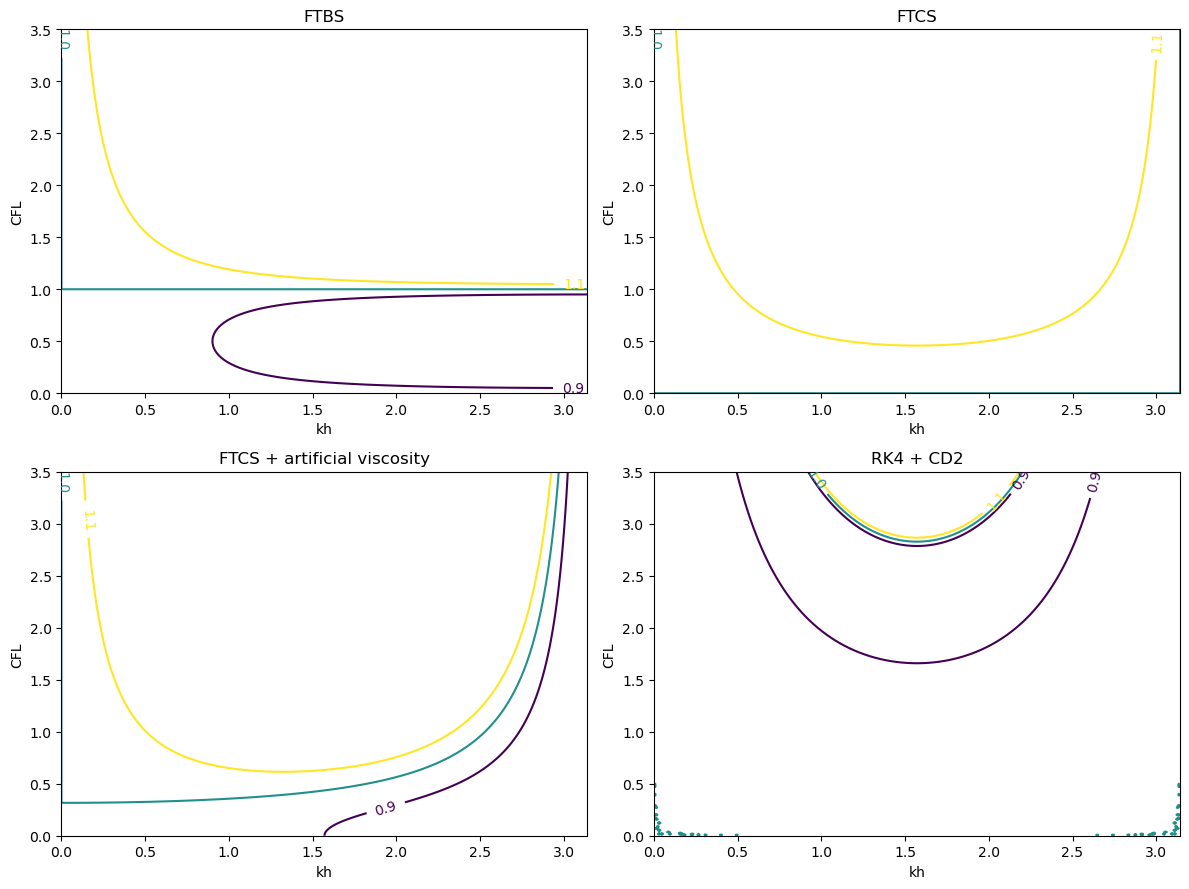

In [4]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# grid for kh and CFL
# ------------------------------------------------
kh = np.linspace(0, np.pi, 400)
CFL = np.linspace(0, 3.5, 400)

KH, CFL_grid = np.meshgrid(kh, CFL)

# artificial viscosity parameter
nu = 0.05

# ------------------------------------------------
# FTBS
# ------------------------------------------------
G_ftbs = 1 - CFL_grid*(1 - np.exp(-1j*KH))
A_ftbs = np.abs(G_ftbs)

# ------------------------------------------------
# FTCS
# ------------------------------------------------
G_ftcs = 1 - 1j*CFL_grid*np.sin(KH)
A_ftcs = np.abs(G_ftcs)

# ------------------------------------------------
# FTCS + viscosity
# ------------------------------------------------
G_visc = 1 - 1j*CFL_grid*np.sin(KH) - 4*nu*np.sin(KH/2)**2
A_visc = np.abs(G_visc)

# ------------------------------------------------
# RK4 + CD2
# ------------------------------------------------
z = -1j*CFL_grid*np.sin(KH)

G_rk4 = 1 + z + z**2/2 + z**3/6 + z**4/24
A_rk4 = np.abs(G_rk4)

# ------------------------------------------------
# contour levels
# ------------------------------------------------
levels = [0.9, 1.0, 1.1]

fig,axs = plt.subplots(2,2,figsize=(12,9))

# ------------------------------------------------
# FTBS
# ------------------------------------------------
cs = axs[0,0].contour(KH,CFL_grid,A_ftbs,levels=levels)
axs[0,0].clabel(cs)
axs[0,0].set_title("FTBS")
axs[0,0].set_xlabel("kh")
axs[0,0].set_ylabel("CFL")

# ------------------------------------------------
# FTCS
# ------------------------------------------------
cs = axs[0,1].contour(KH,CFL_grid,A_ftcs,levels=levels)
axs[0,1].clabel(cs)
axs[0,1].set_title("FTCS")
axs[0,1].set_xlabel("kh")
axs[0,1].set_ylabel("CFL")

# ------------------------------------------------
# FTCS + viscosity
# ------------------------------------------------
cs = axs[1,0].contour(KH,CFL_grid,A_visc,levels=levels)
axs[1,0].clabel(cs)
axs[1,0].set_title("FTCS + artificial viscosity")
axs[1,0].set_xlabel("kh")
axs[1,0].set_ylabel("CFL")

# ------------------------------------------------
# RK4-CD2
# ------------------------------------------------
cs = axs[1,1].contour(KH,CFL_grid,A_rk4,levels=levels)
axs[1,1].clabel(cs)
axs[1,1].set_title("RK4 + CD2")
axs[1,1].set_xlabel("kh")
axs[1,1].set_ylabel("CFL")

plt.tight_layout()
plt.show()

 ## Von Neumann Stability Analysis FTBS: Theory vs simulation comparison

 More deatils can be found in
 https://arxiv.org/pdf/2310.08274

In [ ]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Domain
# =====================================================
L = 2*np.pi
N = 100                 # number of grid points

dx = L/N
x = np.linspace(0,L,N,endpoint=False)

# Fourier mode
m = 1

u = np.sin(m*x)

# =====================================================
# Time parameters
# =====================================================
c = 1
CFL = 0.5

dt = CFL*dx/c

T = 5
nt = int(T/dt)

# =====================================================
# FFT storage
# =====================================================
U_prev = np.fft.fft(u)

G_values = []

# =====================================================
# FTBS solver
# =====================================================
for i in range(nt):

    u_old = u.copy()

    # FTBS update
    u = u_old - CFL*(u_old - np.roll(u_old,1))

    # FFT
    U = np.fft.fft(u)

    # dominant mode index
    idx = m

    G_values.append(U[idx]/U_prev[idx])

    U_prev = U

# =====================================================
# Numerical amplification
# =====================================================
G_sim = np.mean(G_values)

print("Numerical amplification factor from simulation:")
print(G_sim)

# =====================================================
# Theoretical amplification
# =====================================================
theta = 2*np.pi*m/N

G_theory = 1 - CFL*(1 - np.exp(-1j*theta))

print("\nTheoretical amplification factor:")
print(G_theory)

# =====================================================
# Compare magnitude
# =====================================================
print("\nMagnitude comparison:")
print("|G_sim| =",abs(G_sim))
print("|G_theory| =",abs(G_theory))

# =====================================================
# FFT spectrum
# =====================================================
freq = np.fft.fftfreq(N,dx)
U = np.fft.fft(u)

plt.figure(figsize=(7,4))
plt.stem(freq,np.abs(U),basefmt=" ")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("FFT Spectrum")
plt.show()

# dominant frequency
I = np.argmax(np.abs(U))
print("\nDominant FFT frequency:",freq[I])
print("Expected frequency:",m/(2*np.pi))

 ## Von Neumann Stability Analysis SSPRK3-CD2 and RK3-CD2: Theory vs simulation comparison

RK3-CD2 numerical G:
(0.9995071688321548-0.03139010224381182j)

SSPRK3-CD2 numerical G:
(0.9995071688321548-0.031390102243811814j)

Theoretical RK3 amplification:
(0.9995071688321548-0.031390102243811814j)

Magnitude comparison
|RK3_sim| = 0.9999999595328725
|SSPRK3_sim| = 0.9999999595328725
|Theory| = 0.9999999595328725


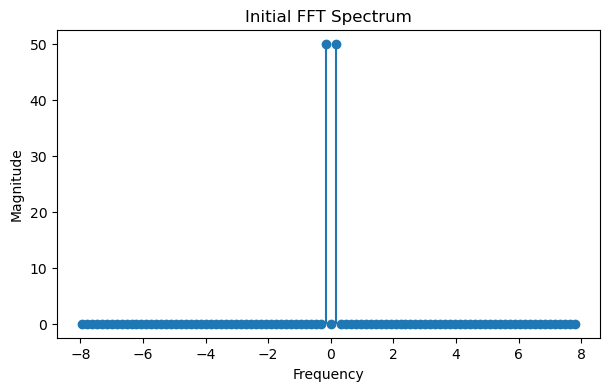

In [2]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Domain
# =====================================================
L = 2*np.pi
N = 100

dx = L/N
x = np.linspace(0,L,N,endpoint=False)

# Fourier mode
m = 1

u0 = np.sin(m*x)

# =====================================================
# Parameters
# =====================================================
c = 1
CFL = 0.5

dt = CFL*dx/c

T = 5
nt = int(T/dt)

# =====================================================
# central difference derivative
# =====================================================
def CD2(u):
    return (np.roll(u,-1) - np.roll(u,1))/(2*dx)

# =====================================================
# RK3 (classical) step
# =====================================================
def RK3_step(u):

    def RHS(u):
        return -c*CD2(u)

    k1 = RHS(u)
    k2 = RHS(u + dt*k1)
    k3 = RHS(u + dt*(0.25*k1 + 0.25*k2))

    return u + dt*(k1/6 + k2/6 + 2*k3/3)

# =====================================================
# SSPRK3 step (Shu–Osher)
# =====================================================
def SSPRK3_step(u):

    def RHS(u):
        return -c*CD2(u)

    u1 = u + dt*RHS(u)
    u2 = 0.75*u + 0.25*(u1 + dt*RHS(u1))
    u3 = (1/3)*u + (2/3)*(u2 + dt*RHS(u2))

    return u3

# =====================================================
# FFT amplification calculation
# =====================================================
def compute_amplification(step_function):

    u = u0.copy()
    U_prev = np.fft.fft(u)

    G_values = []

    for i in range(nt):

        u = step_function(u)

        U = np.fft.fft(u)

        idx = m

        G_values.append(U[idx]/U_prev[idx])

        U_prev = U

    return np.mean(G_values)

# =====================================================
# numerical amplification
# =====================================================
G_RK3_sim = compute_amplification(RK3_step)
G_SSPRK3_sim = compute_amplification(SSPRK3_step)

print("RK3-CD2 numerical G:")
print(G_RK3_sim)

print("\nSSPRK3-CD2 numerical G:")
print(G_SSPRK3_sim)

# =====================================================
# theoretical amplification
# =====================================================
theta = 2*np.pi*m/N

z = -1j*CFL*np.sin(theta)

G_theory = 1 + z + z**2/2 + z**3/6

print("\nTheoretical RK3 amplification:")
print(G_theory)

# =====================================================
# magnitude comparison
# =====================================================
print("\nMagnitude comparison")
print("|RK3_sim| =",abs(G_RK3_sim))
print("|SSPRK3_sim| =",abs(G_SSPRK3_sim))
print("|Theory| =",abs(G_theory))

# =====================================================
# FFT spectrum
# =====================================================
U = np.fft.fft(u0)
freq = np.fft.fftfreq(N,dx)

plt.figure(figsize=(7,4))
plt.stem(freq,np.abs(U),basefmt=" ")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Initial FFT Spectrum")
plt.show()